# Writer-Aware Dynamic Negative Sampling

This notebook investigates whether richer negative-writer exposure improves supervised metric learning on QUWI.

## Controlled comparison

The previous metric-learning baseline used:

- 226 development writers
- Arabic page 1 and page 2 only
- One genuine pair per writer
- One fixed deterministic impostor pair per writer
- CosineEmbeddingLoss
- ImageNet-pretrained ResNet-18
- Layer-4 fine-tuning
- Frozen early backbone
- Frozen BatchNorm running statistics
- Validation-only model selection

The current experiment keeps the model architecture, loss, optimizer, positive pairs, batch size, learning rate, and evaluation protocol unchanged.

The only experimental change is negative sampling.

## Writer-aware dynamic sampling

Each writer continues to contribute exactly:

- One genuine pair per epoch
- One impostor pair per epoch

However, the impostor writer is changed deterministically across epochs.

A different cyclic writer offset is assigned to each epoch. This guarantees:

- No writer is paired with itself as an impostor
- Every writer has exactly one impostor role per epoch
- The per-epoch genuine/impostor ratio remains 1:1
- Negative exposure increases across training
- The experiment remains reproducible from a fixed random seed

Across 10 training epochs, each anchor writer can therefore encounter 10 distinct negative writers instead of repeatedly seeing the same negative writer.

## Research question

Does increasing negative-writer diversity improve writer-disjoint verification performance without changing the metric-learning objective itself?

The fixed validation protocol from the previous notebooks will be used for model selection. Official-test writers will remain excluded from training and model selection.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18

from handwriting_cross_script_research import (
    QUWIDataset,
    load_image_tensor,
)

In [2]:
SEED = 42
EPOCHS = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    PROJECT_ROOT / "pyproject.toml"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists()

IMAGE_DIR = (
    Path.home()
    / "Documents"
    / "Handwriting"
    / "QUWI"
    / "extracted"
    / "images"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "splits"
    / "quwi_writer_disjoint_split_seed42.csv"
)

VALIDATION_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_validation_verification_pairs.csv"
)

TEST_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_official_test_verification_pairs.csv"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "writer_aware_dynamic_sampling"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "writer_aware_dynamic_sampling"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

split_df = pd.read_csv(
    SPLIT_PATH
)

development_df = split_df[
    split_df["experiment_split"]
    == "development_train"
].copy()

validation_df = split_df[
    split_df["experiment_split"]
    == "validation"
].copy()

test_df = split_df[
    split_df["experiment_split"]
    == "official_test"
].copy()

print("Project root:", PROJECT_ROOT)
print("Development images:", len(development_df))
print("Development writers:", development_df["writer"].nunique())
print("Validation writers:", validation_df["writer"].nunique())
print("Official-test writers:", test_df["writer"].nunique())
print("Epochs:", EPOCHS)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

assert len(development_df) == 904
assert development_df["writer"].nunique() == 226
assert validation_df["writer"].nunique() == 56
assert test_df["writer"].nunique() == 193

Project root: /home/arijit/Documents/handwriting-cross-script-research
Development images: 904
Development writers: 226
Validation writers: 56
Official-test writers: 193
Epochs: 10
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
arabic_page1_df = (
    development_df[
        development_df["page_id"] == 1
    ][
        [
            "writer",
            "filename",
        ]
    ]
    .sort_values("writer")
    .reset_index(drop=True)
)

arabic_page2_df = (
    development_df[
        development_df["page_id"] == 2
    ][
        [
            "writer",
            "filename",
        ]
    ]
    .sort_values("writer")
    .reset_index(drop=True)
)

writers = (
    arabic_page1_df[
        "writer"
    ].to_numpy()
)

assert np.array_equal(
    writers,
    arabic_page2_df[
        "writer"
    ].to_numpy(),
)

offset_rng = np.random.default_rng(
    SEED
)

epoch_offsets = offset_rng.choice(
    np.arange(
        1,
        len(writers),
    ),
    size=EPOCHS,
    replace=False,
)

dynamic_pair_frames = []

for epoch_index, offset in enumerate(
    epoch_offsets,
    start=1,
):
    negative_indices = np.roll(
        np.arange(
            len(writers)
        ),
        -int(offset),
    )

    genuine_df = pd.DataFrame(
        {
            "epoch": epoch_index,
            "filename_a": arabic_page1_df[
                "filename"
            ].to_numpy(),
            "filename_b": arabic_page2_df[
                "filename"
            ].to_numpy(),
            "writer_a": writers,
            "writer_b": writers,
            "pair_label": 1,
            "pair_type": "genuine",
            "negative_offset": 0,
        }
    )

    impostor_df = pd.DataFrame(
        {
            "epoch": epoch_index,
            "filename_a": arabic_page1_df[
                "filename"
            ].to_numpy(),
            "filename_b": arabic_page2_df[
                "filename"
            ].to_numpy()[
                negative_indices
            ],
            "writer_a": writers,
            "writer_b": writers[
                negative_indices
            ],
            "pair_label": 0,
            "pair_type": "impostor",
            "negative_offset": int(
                offset
            ),
        }
    )

    epoch_pairs_df = pd.concat(
        [
            genuine_df,
            impostor_df,
        ],
        ignore_index=True,
    )

    epoch_pairs_df = (
        epoch_pairs_df
        .sample(
            frac=1.0,
            random_state=SEED
            + epoch_index,
        )
        .reset_index(drop=True)
    )

    dynamic_pair_frames.append(
        epoch_pairs_df
    )

dynamic_training_pairs_df = pd.concat(
    dynamic_pair_frames,
    ignore_index=True,
)

impostor_exposure_df = (
    dynamic_training_pairs_df[
        dynamic_training_pairs_df[
            "pair_label"
        ] == 0
    ]
    .groupby(
        "writer_a"
    )
    .agg(
        impostor_pairs=(
            "writer_b",
            "size",
        ),
        distinct_negative_writers=(
            "writer_b",
            "nunique",
        ),
    )
    .reset_index()
)

epoch_pair_summary_df = (
    dynamic_training_pairs_df
    .groupby(
        [
            "epoch",
            "pair_type",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

print(
    "Epoch offsets:",
    epoch_offsets.tolist(),
)

print(
    "Total scheduled training pairs:",
    len(
        dynamic_training_pairs_df
    ),
)

print(
    "Pairs per epoch:",
    len(
        dynamic_training_pairs_df
    ) // EPOCHS,
)

print(
    "Distinct negative writers per anchor min:",
    impostor_exposure_df[
        "distinct_negative_writers"
    ].min(),
)

print(
    "Distinct negative writers per anchor max:",
    impostor_exposure_df[
        "distinct_negative_writers"
    ].max(),
)

print(
    "Impostor self-pairs:",
    (
        dynamic_training_pairs_df.loc[
            dynamic_training_pairs_df[
                "pair_label"
            ] == 0,
            "writer_a",
        ].to_numpy()
        ==
        dynamic_training_pairs_df.loc[
            dynamic_training_pairs_df[
                "pair_label"
            ] == 0,
            "writer_b",
        ].to_numpy()
    ).sum(),
)

display(
    epoch_pair_summary_df
)

assert len(arabic_page1_df) == 226
assert len(arabic_page2_df) == 226
assert len(dynamic_training_pairs_df) == 4520
assert impostor_exposure_df[
    "distinct_negative_writers"
].eq(10).all()
assert epoch_pair_summary_df[
    "genuine"
].eq(226).all()
assert epoch_pair_summary_df[
    "impostor"
].eq(226).all()

Epoch offsets: [222, 168, 20, 143, 97, 96, 156, 22, 46, 190]
Total scheduled training pairs: 4520
Pairs per epoch: 452
Distinct negative writers per anchor min: 10
Distinct negative writers per anchor max: 10
Impostor self-pairs: 0


pair_type,genuine,impostor
epoch,,
1,226,226
2,226,226
3,226,226
4,226,226
5,226,226
6,226,226
7,226,226
8,226,226
9,226,226


In [4]:
class QUWIPairDataset(Dataset):
    def __init__(
        self,
        pair_dataframe,
        image_dir,
    ):
        self.pairs = (
            pair_dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.image_dir = Path(
            image_dir
        )

    def __len__(self):
        return len(
            self.pairs
        )

    def __getitem__(
        self,
        index,
    ):
        row = self.pairs.iloc[
            index
        ]

        image_a, _ = load_image_tensor(
            self.image_dir
            / row["filename_a"]
        )

        image_b, _ = load_image_tensor(
            self.image_dir
            / row["filename_b"]
        )

        return {
            "image_a": image_a,
            "image_b": image_b,
            "pair_label": torch.tensor(
                row["pair_label"],
                dtype=torch.float32,
            ),
            "writer_a": int(
                row["writer_a"]
            ),
            "writer_b": int(
                row["writer_b"]
            ),
            "filename_a": row[
                "filename_a"
            ],
            "filename_b": row[
                "filename_b"
            ],
        }


BATCH_SIZE = 8
NUM_WORKERS = 0


def create_epoch_loader(
    epoch,
):
    epoch_pairs_df = (
        dynamic_training_pairs_df[
            dynamic_training_pairs_df[
                "epoch"
            ] == epoch
        ]
        .reset_index(drop=True)
    )

    dataset = QUWIPairDataset(
        epoch_pairs_df,
        IMAGE_DIR,
    )

    generator = (
        torch.Generator()
        .manual_seed(
            SEED + epoch
        )
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )

    return (
        epoch_pairs_df,
        dataset,
        loader,
    )


epoch1_pairs_df, epoch1_dataset, epoch1_loader = (
    create_epoch_loader(
        1
    )
)

epoch10_pairs_df, epoch10_dataset, epoch10_loader = (
    create_epoch_loader(
        10
    )
)

epoch1_batch = next(
    iter(epoch1_loader)
)

print(
    "Epoch-1 dataset:",
    len(epoch1_dataset),
)

print(
    "Epoch-10 dataset:",
    len(epoch10_dataset),
)

print(
    "Epoch-1 batches:",
    len(epoch1_loader),
)

print(
    "Epoch-1 image A shape:",
    epoch1_batch[
        "image_a"
    ].shape,
)

print(
    "Epoch-1 image B shape:",
    epoch1_batch[
        "image_b"
    ].shape,
)

print(
    "Epoch-1 label counts:",
    epoch1_pairs_df[
        "pair_label"
    ].value_counts().sort_index().to_dict(),
)

print(
    "Epoch-10 label counts:",
    epoch10_pairs_df[
        "pair_label"
    ].value_counts().sort_index().to_dict(),
)

print(
    "Epoch-1 negative offset:",
    epoch1_pairs_df.loc[
        epoch1_pairs_df[
            "pair_label"
        ] == 0,
        "negative_offset",
    ].unique().tolist(),
)

print(
    "Epoch-10 negative offset:",
    epoch10_pairs_df.loc[
        epoch10_pairs_df[
            "pair_label"
        ] == 0,
        "negative_offset",
    ].unique().tolist(),
)

assert len(epoch1_dataset) == 452
assert len(epoch10_dataset) == 452
assert len(epoch1_loader) == 57
assert epoch1_batch["image_a"].shape == (
    8,
    3,
    384,
    384,
)
assert epoch1_batch["image_b"].shape == (
    8,
    3,
    384,
    384,
)

Epoch-1 dataset: 452
Epoch-10 dataset: 452
Epoch-1 batches: 57
Epoch-1 image A shape: torch.Size([8, 3, 384, 384])
Epoch-1 image B shape: torch.Size([8, 3, 384, 384])
Epoch-1 label counts: {0: 226, 1: 226}
Epoch-10 label counts: {0: 226, 1: 226}
Epoch-1 negative offset: [222]
Epoch-10 negative offset: [190]


In [5]:
IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406,
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225,
)


class MetricEmbeddingModel(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        backbone.fc = nn.Identity()

        self.feature_extractor = backbone

        self.register_buffer(
            "normalization_mean",
            torch.tensor(
                IMAGENET_MEAN
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        self.register_buffer(
            "normalization_std",
            torch.tensor(
                IMAGENET_STD
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        for parameter in (
            self.feature_extractor
            .parameters()
        ):
            parameter.requires_grad = False

        for parameter in (
            self.feature_extractor
            .layer4
            .parameters()
        ):
            parameter.requires_grad = True

    def train(
        self,
        mode=True,
    ):
        super().train(mode)

        self.feature_extractor.eval()

        return self

    def forward(
        self,
        images,
    ):
        images = (
            images
            - self.normalization_mean
        ) / self.normalization_std

        features = self.feature_extractor(
            images
        )

        return F.normalize(
            features,
            p=2,
            dim=1,
        )


metric_model = (
    MetricEmbeddingModel()
    .to(DEVICE)
)

LOSS_MARGIN = 0.5

criterion = nn.CosineEmbeddingLoss(
    margin=LOSS_MARGIN,
)

optimizer = torch.optim.AdamW(
    metric_model
    .feature_extractor
    .layer4
    .parameters(),
    lr=1e-5,
    weight_decay=1e-4,
)

total_parameters = sum(
    parameter.numel()
    for parameter in metric_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in metric_model.parameters()
    if parameter.requires_grad
)

metric_model.train()

sample_images = epoch1_batch[
    "image_a"
].to(
    DEVICE,
    non_blocking=True,
)

with torch.no_grad():
    sample_embeddings = metric_model(
        sample_images
    )

print(
    "Total parameters:",
    total_parameters,
)

print(
    "Trainable parameters:",
    trainable_parameters,
)

print(
    "Frozen parameters:",
    total_parameters
    - trainable_parameters,
)

print(
    "Embedding shape:",
    sample_embeddings.shape,
)

print(
    "Mean embedding norm:",
    round(
        sample_embeddings.norm(
            dim=1
        ).mean().item(),
        6,
    ),
)

print(
    "Loss margin:",
    LOSS_MARGIN,
)

print(
    "Layer4 training flag:",
    metric_model
    .feature_extractor
    .layer4
    .training,
)

assert total_parameters == 11_176_512
assert trainable_parameters == 8_393_728
assert sample_embeddings.shape == (
    8,
    512,
)
assert (
    metric_model
    .feature_extractor
    .layer4
    .training
    is False
)

Total parameters: 11176512
Trainable parameters: 8393728
Frozen parameters: 2782784
Embedding shape: torch.Size([8, 512])
Mean embedding norm: 1.0
Loss margin: 0.5
Layer4 training flag: False


In [6]:
metric_model.train()

optimizer.zero_grad(
    set_to_none=True
)

batch_a = epoch1_batch[
    "image_a"
].to(
    DEVICE,
    non_blocking=True,
)

batch_b = epoch1_batch[
    "image_b"
].to(
    DEVICE,
    non_blocking=True,
)

batch_labels = epoch1_batch[
    "pair_label"
].to(
    DEVICE,
    non_blocking=True,
)

targets = torch.where(
    batch_labels == 1,
    torch.ones_like(
        batch_labels
    ),
    -torch.ones_like(
        batch_labels
    ),
)

bn_layer = (
    metric_model
    .feature_extractor
    .layer4[0]
    .bn1
)

bn_mean_before = (
    bn_layer
    .running_mean
    .detach()
    .clone()
)

embedding_a = metric_model(
    batch_a
)

embedding_b = metric_model(
    batch_b
)

smoke_loss = criterion(
    embedding_a,
    embedding_b,
    targets,
)

smoke_loss.backward()

layer4_grad_norm = torch.sqrt(
    sum(
        parameter.grad.detach().norm() ** 2
        for parameter in (
            metric_model
            .feature_extractor
            .layer4
            .parameters()
        )
        if parameter.grad is not None
    )
)

early_backbone_gradients = sum(
    parameter.grad is not None
    for name, parameter in (
        metric_model
        .feature_extractor
        .named_parameters()
    )
    if not name.startswith(
        "layer4."
    )
)

bn_mean_after = (
    bn_layer
    .running_mean
    .detach()
    .clone()
)

print(
    "Smoke loss:",
    round(
        smoke_loss.item(),
        6,
    ),
)

print(
    "Layer4 gradient norm:",
    round(
        layer4_grad_norm.item(),
        6,
    ),
)

print(
    "Finite layer4 gradient:",
    torch.isfinite(
        layer4_grad_norm
    ).item(),
)

print(
    "Early-backbone parameters with gradients:",
    early_backbone_gradients,
)

print(
    "BatchNorm running mean unchanged:",
    torch.equal(
        bn_mean_before,
        bn_mean_after,
    ),
)

optimizer.zero_grad(
    set_to_none=True
)

assert torch.isfinite(
    layer4_grad_norm
)

assert layer4_grad_norm.item() > 0

assert early_backbone_gradients == 0

assert torch.equal(
    bn_mean_before,
    bn_mean_after,
)

Smoke loss: 0.272705
Layer4 gradient norm: 0.559977
Finite layer4 gradient: True
Early-backbone parameters with gradients: 0
BatchNorm running mean unchanged: True


In [7]:
validation_pairs_df = pd.read_csv(
    VALIDATION_PAIR_PATH
)

validation_dataset = QUWIDataset(
    metadata=validation_df,
    image_dir=IMAGE_DIR,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


@torch.inference_mode()
def extract_embeddings(
    model,
    loader,
):
    model.eval()

    filenames = []
    embedding_batches = []

    for batch in loader:
        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        embeddings = model(
            images
        )

        embedding_batches.append(
            embeddings.cpu()
        )

        filenames.extend(
            batch["filename"]
        )

    return (
        filenames,
        torch.cat(
            embedding_batches,
            dim=0,
        ),
    )


def score_pairs(
    pair_df,
    filenames,
    embeddings,
):
    filename_to_index = {
        filename: index
        for index, filename
        in enumerate(
            filenames
        )
    }

    index_a = torch.tensor(
        [
            filename_to_index[
                filename
            ]
            for filename
            in pair_df[
                "filename_a"
            ]
        ],
        dtype=torch.long,
    )

    index_b = torch.tensor(
        [
            filename_to_index[
                filename
            ]
            for filename
            in pair_df[
                "filename_b"
            ]
        ],
        dtype=torch.long,
    )

    return (
        embeddings[
            index_a
        ]
        * embeddings[
            index_b
        ]
    ).sum(
        dim=1
    ).numpy()


def verification_metrics(
    labels,
    scores,
):
    labels = np.asarray(
        labels
    )

    scores = np.asarray(
        scores
    )

    auc = roc_auc_score(
        labels,
        scores,
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1,
    )

    fnr = 1.0 - tpr

    difference = (
        fpr - fnr
    )

    eer = np.interp(
        0.0,
        difference,
        fpr,
    )

    eer_threshold = np.interp(
        0.0,
        difference,
        thresholds,
    )

    return {
        "roc_auc": float(
            auc
        ),
        "eer": float(
            eer
        ),
        "eer_percent": float(
            eer * 100
        ),
        "eer_threshold": float(
            eer_threshold
        ),
    }


validation_filenames, epoch0_embeddings = (
    extract_embeddings(
        metric_model,
        validation_loader,
    )
)

epoch0_scores = score_pairs(
    validation_pairs_df,
    validation_filenames,
    epoch0_embeddings,
)

epoch0_metrics = verification_metrics(
    validation_pairs_df[
        "pair_label"
    ].to_numpy(),
    epoch0_scores,
)

print(
    "Validation embeddings:",
    epoch0_embeddings.shape,
)

print(
    "Validation scores:",
    len(
        epoch0_scores
    ),
)

print(
    "Epoch-0 ROC-AUC:",
    round(
        epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Epoch-0 EER:",
    round(
        epoch0_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Epoch-0 EER threshold:",
    round(
        epoch0_metrics[
            "eer_threshold"
        ],
        6,
    ),
)

print(
    "All scores finite:",
    np.isfinite(
        epoch0_scores
    ).all(),
)

assert epoch0_embeddings.shape == (
    224,
    512,
)

assert len(
    epoch0_scores
) == 18_816

assert np.isfinite(
    epoch0_scores
).all()

assert np.isclose(
    epoch0_metrics[
        "roc_auc"
    ],
    0.612379,
    atol=1e-5,
)

assert np.isclose(
    epoch0_metrics[
        "eer_percent"
    ],
    43.1548,
    atol=1e-3,
)

Validation embeddings: torch.Size([224, 512])
Validation scores: 18816
Epoch-0 ROC-AUC: 0.612379
Epoch-0 EER: 43.1548 %
Epoch-0 EER threshold: 0.939745
All scores finite: True


In [8]:
MAX_GRAD_NORM = 5.0

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "resnet18_dynamic_sampling_best.pt"
)


def train_metric_epoch(
    model,
    loader,
    optimizer,
    criterion,
):
    model.train()

    total_loss = 0.0
    total_pairs = 0

    genuine_similarities = []
    impostor_similarities = []
    gradient_norms = []

    skipped_steps = 0

    for batch in loader:
        image_a = batch[
            "image_a"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        image_b = batch[
            "image_b"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch[
            "pair_label"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        targets = torch.where(
            labels == 1,
            torch.ones_like(
                labels
            ),
            -torch.ones_like(
                labels
            ),
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        embedding_a = model(
            image_a
        )

        embedding_b = model(
            image_b
        )

        loss = criterion(
            embedding_a,
            embedding_b,
            targets,
        )

        loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                model
                .feature_extractor
                .layer4
                .parameters(),
                max_norm=MAX_GRAD_NORM,
            )
        )

        if torch.isfinite(
            gradient_norm
        ):
            optimizer.step()
        else:
            skipped_steps += 1

        similarities = (
            embedding_a
            * embedding_b
        ).sum(
            dim=1
        ).detach()

        genuine_mask = (
            labels == 1
        )

        impostor_mask = (
            labels == 0
        )

        genuine_similarities.extend(
            similarities[
                genuine_mask
            ].cpu().tolist()
        )

        impostor_similarities.extend(
            similarities[
                impostor_mask
            ].cpu().tolist()
        )

        gradient_norms.append(
            float(
                gradient_norm
                .detach()
                .cpu()
            )
        )

        batch_size = len(
            labels
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        total_pairs += batch_size

    genuine_mean = float(
        np.mean(
            genuine_similarities
        )
    )

    impostor_mean = float(
        np.mean(
            impostor_similarities
        )
    )

    return {
        "loss": float(
            total_loss
            / total_pairs
        ),
        "genuine_similarity": genuine_mean,
        "impostor_similarity": impostor_mean,
        "training_score_gap": float(
            genuine_mean
            - impostor_mean
        ),
        "mean_gradient_norm": float(
            np.mean(
                gradient_norms
            )
        ),
        "max_gradient_norm": float(
            np.max(
                gradient_norms
            )
        ),
        "skipped_steps": int(
            skipped_steps
        ),
    }


def evaluate_validation(
    model,
):
    filenames, embeddings = (
        extract_embeddings(
            model,
            validation_loader,
        )
    )

    scores = score_pairs(
        validation_pairs_df,
        filenames,
        embeddings,
    )

    metrics = verification_metrics(
        validation_pairs_df[
            "pair_label"
        ].to_numpy(),
        scores,
    )

    return (
        metrics,
        embeddings,
        scores,
    )


torch.save(
    {
        "epoch": 0,
        "model_state_dict": (
            metric_model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "validation_metrics": (
            epoch0_metrics
        ),
        "configuration": {
            "seed": SEED,
            "epochs": EPOCHS,
            "loss": "CosineEmbeddingLoss",
            "margin": LOSS_MARGIN,
            "learning_rate": 1e-5,
            "weight_decay": 1e-4,
            "max_gradient_norm": (
                MAX_GRAD_NORM
            ),
            "pairs_per_epoch": 452,
            "genuine_pairs_per_epoch": 226,
            "impostor_pairs_per_epoch": 226,
            "distinct_negative_writers_per_anchor": 10,
            "epoch_offsets": (
                epoch_offsets.tolist()
            ),
        },
    },
    BEST_CHECKPOINT_PATH,
)

print(
    "Epoch-0 checkpoint saved:",
    BEST_CHECKPOINT_PATH.exists(),
)

print(
    "Initial validation AUC:",
    round(
        epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Initial validation EER:",
    round(
        epoch0_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Negative writers per anchor:",
    int(
        impostor_exposure_df[
            "distinct_negative_writers"
        ].min()
    ),
)

Epoch-0 checkpoint saved: True
Initial validation AUC: 0.612379
Initial validation EER: 43.1548 %
Negative writers per anchor: 10


In [9]:
history_rows = [
    {
        "epoch": 0,
        "negative_offset": 0,
        "train_loss": np.nan,
        "train_genuine_similarity": np.nan,
        "train_impostor_similarity": np.nan,
        "train_score_gap": np.nan,
        "mean_gradient_norm": np.nan,
        "max_gradient_norm": np.nan,
        "skipped_steps": 0,
        "validation_roc_auc": (
            epoch0_metrics[
                "roc_auc"
            ]
        ),
        "validation_eer_percent": (
            epoch0_metrics[
                "eer_percent"
            ]
        ),
        "validation_eer_threshold": (
            epoch0_metrics[
                "eer_threshold"
            ]
        ),
    }
]

best_epoch = 0

best_validation_auc = (
    epoch0_metrics[
        "roc_auc"
    ]
)

best_validation_eer = (
    epoch0_metrics[
        "eer_percent"
    ]
)

for epoch in range(
    1,
    EPOCHS + 1,
):
    (
        epoch_pairs_df,
        _,
        epoch_loader,
    ) = create_epoch_loader(
        epoch
    )

    negative_offset = int(
        epoch_pairs_df.loc[
            epoch_pairs_df[
                "pair_label"
            ] == 0,
            "negative_offset",
        ].iloc[0]
    )

    train_metrics = train_metric_epoch(
        metric_model,
        epoch_loader,
        optimizer,
        criterion,
    )

    (
        validation_metrics,
        _,
        _,
    ) = evaluate_validation(
        metric_model
    )

    history_rows.append(
        {
            "epoch": epoch,
            "negative_offset": (
                negative_offset
            ),
            "train_loss": train_metrics[
                "loss"
            ],
            "train_genuine_similarity": train_metrics[
                "genuine_similarity"
            ],
            "train_impostor_similarity": train_metrics[
                "impostor_similarity"
            ],
            "train_score_gap": train_metrics[
                "training_score_gap"
            ],
            "mean_gradient_norm": train_metrics[
                "mean_gradient_norm"
            ],
            "max_gradient_norm": train_metrics[
                "max_gradient_norm"
            ],
            "skipped_steps": train_metrics[
                "skipped_steps"
            ],
            "validation_roc_auc": validation_metrics[
                "roc_auc"
            ],
            "validation_eer_percent": validation_metrics[
                "eer_percent"
            ],
            "validation_eer_threshold": validation_metrics[
                "eer_threshold"
            ],
        }
    )

    auc_improved = (
        validation_metrics[
            "roc_auc"
        ]
        > best_validation_auc
        + 1e-12
    )

    auc_tied = np.isclose(
        validation_metrics[
            "roc_auc"
        ],
        best_validation_auc,
        atol=1e-12,
        rtol=0.0,
    )

    eer_improved_on_tie = (
        auc_tied
        and validation_metrics[
            "eer_percent"
        ]
        < best_validation_eer
    )

    if (
        auc_improved
        or eer_improved_on_tie
    ):
        best_epoch = epoch

        best_validation_auc = (
            validation_metrics[
                "roc_auc"
            ]
        )

        best_validation_eer = (
            validation_metrics[
                "eer_percent"
            ]
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": (
                    metric_model
                    .state_dict()
                ),
                "optimizer_state_dict": (
                    optimizer
                    .state_dict()
                ),
                "training_metrics": (
                    train_metrics
                ),
                "validation_metrics": (
                    validation_metrics
                ),
                "configuration": {
                    "seed": SEED,
                    "loss": (
                        "CosineEmbeddingLoss"
                    ),
                    "margin": LOSS_MARGIN,
                    "learning_rate": 1e-5,
                    "weight_decay": 1e-4,
                    "max_gradient_norm": (
                        MAX_GRAD_NORM
                    ),
                    "negative_offset": (
                        negative_offset
                    ),
                    "epoch_offsets": (
                        epoch_offsets
                        .tolist()
                    ),
                },
            },
            BEST_CHECKPOINT_PATH,
        )

    print(
        f"Epoch {epoch:02d} | "
        f"offset {negative_offset:03d} | "
        f"loss {train_metrics['loss']:.4f} | "
        f"genuine {train_metrics['genuine_similarity']:.4f} | "
        f"impostor {train_metrics['impostor_similarity']:.4f} | "
        f"gap {train_metrics['training_score_gap']:.4f} | "
        f"val AUC {validation_metrics['roc_auc']:.4f} | "
        f"val EER {validation_metrics['eer_percent']:.2f}% | "
        f"grad {train_metrics['mean_gradient_norm']:.4f} | "
        f"skipped {train_metrics['skipped_steps']}"
    )

training_history_df = pd.DataFrame(
    history_rows
)

print()
print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation AUC:",
    round(
        best_validation_auc,
        6,
    ),
)

print(
    "Best validation EER:",
    round(
        best_validation_eer,
        4,
    ),
    "%",
)

print(
    "Best checkpoint exists:",
    BEST_CHECKPOINT_PATH.exists(),
)

print(
    "Total skipped optimizer steps:",
    int(
        training_history_df[
            "skipped_steps"
        ].sum()
    ),
)

Epoch 01 | offset 222 | loss 0.2348 | genuine 0.9356 | impostor 0.9053 | gap 0.0303 | val AUC 0.6306 | val EER 40.55% | grad 0.6454 | skipped 0
Epoch 02 | offset 168 | loss 0.2177 | genuine 0.8729 | impostor 0.8082 | gap 0.0648 | val AUC 0.6702 | val EER 38.64% | grad 1.3654 | skipped 0
Epoch 03 | offset 020 | loss 0.1816 | genuine 0.8302 | impostor 0.6815 | gap 0.1487 | val AUC 0.6939 | val EER 36.90% | grad 1.8642 | skipped 0
Epoch 04 | offset 143 | loss 0.1590 | genuine 0.8237 | impostor 0.6202 | gap 0.2035 | val AUC 0.7209 | val EER 34.92% | grad 2.2356 | skipped 0
Epoch 05 | offset 097 | loss 0.1593 | genuine 0.8098 | impostor 0.5854 | gap 0.2243 | val AUC 0.7243 | val EER 34.82% | grad 2.3087 | skipped 0
Epoch 06 | offset 096 | loss 0.1469 | genuine 0.8338 | impostor 0.5907 | gap 0.2431 | val AUC 0.7352 | val EER 33.93% | grad 2.5901 | skipped 0
Epoch 07 | offset 156 | loss 0.1374 | genuine 0.8420 | impostor 0.5671 | gap 0.2748 | val AUC 0.7373 | val EER 32.87% | grad 2.5796 | sk

In [10]:
best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

best_dynamic_model = (
    MetricEmbeddingModel()
    .to(DEVICE)
)

best_dynamic_model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

best_dynamic_model.eval()

test_pairs_df = pd.read_csv(
    TEST_PAIR_PATH
)

test_dataset = QUWIDataset(
    metadata=test_df,
    image_dir=IMAGE_DIR,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

best_validation_filenames, best_validation_embeddings = (
    extract_embeddings(
        best_dynamic_model,
        validation_loader,
    )
)

best_test_filenames, best_test_embeddings = (
    extract_embeddings(
        best_dynamic_model,
        test_loader,
    )
)

best_validation_scores = score_pairs(
    validation_pairs_df,
    best_validation_filenames,
    best_validation_embeddings,
)

best_test_scores = score_pairs(
    test_pairs_df,
    best_test_filenames,
    best_test_embeddings,
)

best_validation_metrics = verification_metrics(
    validation_pairs_df[
        "pair_label"
    ].to_numpy(),
    best_validation_scores,
)

best_test_metrics = verification_metrics(
    test_pairs_df[
        "pair_label"
    ].to_numpy(),
    best_test_scores,
)

print(
    "Loaded checkpoint epoch:",
    best_checkpoint["epoch"],
)

print(
    "Validation embeddings:",
    best_validation_embeddings.shape,
)

print(
    "Official-test embeddings:",
    best_test_embeddings.shape,
)

print(
    "Dynamic validation ROC-AUC:",
    round(
        best_validation_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Dynamic validation EER:",
    round(
        best_validation_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Dynamic official-test ROC-AUC:",
    round(
        best_test_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Dynamic official-test EER:",
    round(
        best_test_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Validation scores finite:",
    np.isfinite(
        best_validation_scores
    ).all(),
)

print(
    "Official-test scores finite:",
    np.isfinite(
        best_test_scores
    ).all(),
)

assert best_checkpoint["epoch"] == 8
assert best_validation_embeddings.shape == (
    224,
    512,
)
assert best_test_embeddings.shape == (
    772,
    512,
)
assert len(best_validation_scores) == 18_816
assert len(best_test_scores) == 223_494

Loaded checkpoint epoch: 8
Validation embeddings: torch.Size([224, 512])
Official-test embeddings: torch.Size([772, 512])
Dynamic validation ROC-AUC: 0.741935
Dynamic validation EER: 32.7327 %
Dynamic official-test ROC-AUC: 0.764084
Dynamic official-test EER: 31.1744 %
Validation scores finite: True
Official-test scores finite: True


In [11]:
def evaluate_conditions(
    pair_df,
    scores,
    split_name,
):
    scored_df = pair_df.copy()

    scored_df[
        "dynamic_cosine_score"
    ] = scores

    rows = []

    aggregate = verification_metrics(
        scored_df[
            "pair_label"
        ].to_numpy(),
        scored_df[
            "dynamic_cosine_score"
        ].to_numpy(),
    )

    rows.append(
        {
            "experiment_split": split_name,
            "condition_id": "all_conditions",
            **aggregate,
        }
    )

    for condition_id, condition_df in scored_df.groupby(
        "condition_id",
        sort=False,
    ):
        metrics = verification_metrics(
            condition_df[
                "pair_label"
            ].to_numpy(),
            condition_df[
                "dynamic_cosine_score"
            ].to_numpy(),
        )

        rows.append(
            {
                "experiment_split": split_name,
                "condition_id": condition_id,
                **metrics,
            }
        )

    return pd.DataFrame(
        rows
    )


dynamic_condition_results_df = pd.concat(
    [
        evaluate_conditions(
            validation_pairs_df,
            best_validation_scores,
            "validation",
        ),
        evaluate_conditions(
            test_pairs_df,
            best_test_scores,
            "official_test",
        ),
    ],
    ignore_index=True,
)

STATIC_RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "supervised_metric_learning"
    / "verification_condition_results.csv"
)

static_condition_results_df = pd.read_csv(
    STATIC_RESULTS_PATH
)

static_dynamic_comparison_df = (
    static_condition_results_df[
        [
            "experiment_split",
            "condition_id",
            "roc_auc",
            "eer_percent",
        ]
    ]
    .merge(
        dynamic_condition_results_df[
            [
                "experiment_split",
                "condition_id",
                "roc_auc",
                "eer_percent",
            ]
        ],
        on=[
            "experiment_split",
            "condition_id",
        ],
        suffixes=(
            "_static",
            "_dynamic",
        ),
    )
)

static_dynamic_comparison_df[
    "auc_change"
] = (
    static_dynamic_comparison_df[
        "roc_auc_dynamic"
    ]
    - static_dynamic_comparison_df[
        "roc_auc_static"
    ]
)

static_dynamic_comparison_df[
    "eer_change_points"
] = (
    static_dynamic_comparison_df[
        "eer_percent_dynamic"
    ]
    - static_dynamic_comparison_df[
        "eer_percent_static"
    ]
)

display(
    static_dynamic_comparison_df.round(
        4
    )
)

aggregate_comparison_df = (
    static_dynamic_comparison_df[
        static_dynamic_comparison_df[
            "condition_id"
        ] == "all_conditions"
    ]
)

display(
    aggregate_comparison_df.round(
        6
    )
)

condition_only_df = (
    static_dynamic_comparison_df[
        static_dynamic_comparison_df[
            "condition_id"
        ] != "all_conditions"
    ]
)

print(
    "Dynamic sampling improved condition AUC:",
    (
        condition_only_df[
            "auc_change"
        ] > 0
    ).sum(),
    "of",
    len(
        condition_only_df
    ),
)

print(
    "Dynamic sampling reduced condition EER:",
    (
        condition_only_df[
            "eer_change_points"
        ] < 0
    ).sum(),
    "of",
    len(
        condition_only_df
    ),
)

print(
    "Mean condition AUC change:",
    round(
        condition_only_df[
            "auc_change"
        ].mean(),
        6,
    ),
)

assert len(
    dynamic_condition_results_df
) == 14

assert len(
    static_dynamic_comparison_df
) == 14

,experiment_split,condition_id,roc_auc_static,eer_percent_static,roc_auc_dynamic,eer_percent_dynamic,auc_change,eer_change_points
0,validation,all_conditions,0.7386,32.6948,0.7419,32.7327,0.0033,0.0379
1,validation,arabic_variable_same,0.8604,21.4286,0.8543,21.7857,-0.0061,0.3571
2,validation,english_variable_same,0.8118,25.9091,0.8084,25.8442,-0.0035,-0.0649
3,validation,cross_variable_variable,0.6931,35.7143,0.7033,34.5130,0.0102,-1.2013
4,validation,cross_variable_same,0.6848,39.2532,0.6784,37.5000,-0.0064,-1.7532
5,validation,cross_same_variable,0.6969,35.7143,0.7195,32.6299,0.0226,-3.0844
6,validation,cross_same_same,0.7247,33.9286,0.7217,33.3766,-0.0030,-0.5519
7,official_test,all_conditions,0.7583,31.5199,0.7641,31.1744,0.0058,-0.3454
8,official_test,arabic_variable_same,0.8672,20.2073,0.8601,21.3569,-0.0071,1.1496
9,official_test,english_variable_same,0.8550,22.2798,0.8541,21.7617,-0.0009,-0.5181


,experiment_split,condition_id,roc_auc_static,eer_percent_static,roc_auc_dynamic,eer_percent_dynamic,auc_change,eer_change_points
0,validation,all_conditions,0.738648,32.694805,0.741935,32.732684,0.003287,0.037879
7,official_test,all_conditions,0.758257,31.519862,0.764084,31.174439,0.005827,-0.345423


Dynamic sampling improved condition AUC: 5 of 12
Dynamic sampling reduced condition EER: 10 of 12
Mean condition AUC change: 0.003259


In [12]:
condition_metadata_df = (
    validation_pairs_df[
        [
            "condition_id",
            "script_relation",
            "text_relation",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

static_family_df = (
    condition_only_df[
        [
            "experiment_split",
            "condition_id",
            "roc_auc_static",
            "eer_percent_static",
        ]
    ]
    .rename(
        columns={
            "roc_auc_static": "roc_auc",
            "eer_percent_static": "eer_percent",
        }
    )
)

static_family_df[
    "sampling_strategy"
] = "static"

dynamic_family_df = (
    condition_only_df[
        [
            "experiment_split",
            "condition_id",
            "roc_auc_dynamic",
            "eer_percent_dynamic",
        ]
    ]
    .rename(
        columns={
            "roc_auc_dynamic": "roc_auc",
            "eer_percent_dynamic": "eer_percent",
        }
    )
)

dynamic_family_df[
    "sampling_strategy"
] = "dynamic"

sampling_family_df = pd.concat(
    [
        static_family_df,
        dynamic_family_df,
    ],
    ignore_index=True,
)

sampling_family_df = (
    sampling_family_df
    .merge(
        condition_metadata_df,
        on="condition_id",
        how="left",
    )
)

sampling_family_df[
    "script_family"
] = np.where(
    sampling_family_df[
        "script_relation"
    ] == "cross_script",
    "cross_script",
    "within_script",
)

sampling_family_summary_df = (
    sampling_family_df
    .groupby(
        [
            "experiment_split",
            "sampling_strategy",
            "script_family",
        ],
        as_index=False,
    )
    .agg(
        conditions=(
            "condition_id",
            "nunique",
        ),
        macro_roc_auc=(
            "roc_auc",
            "mean",
        ),
        macro_eer_percent=(
            "eer_percent",
            "mean",
        ),
    )
)

display(
    sampling_family_summary_df.round(
        4
    )
)

sampling_gap_rows = []

for split_name in [
    "validation",
    "official_test",
]:
    for strategy in [
        "static",
        "dynamic",
    ]:
        rows = sampling_family_summary_df[
            (
                sampling_family_summary_df[
                    "experiment_split"
                ] == split_name
            )
            & (
                sampling_family_summary_df[
                    "sampling_strategy"
                ] == strategy
            )
        ]

        within_row = rows[
            rows[
                "script_family"
            ] == "within_script"
        ].iloc[0]

        cross_row = rows[
            rows[
                "script_family"
            ] == "cross_script"
        ].iloc[0]

        sampling_gap_rows.append(
            {
                "experiment_split": split_name,
                "sampling_strategy": strategy,
                "within_script_auc": within_row[
                    "macro_roc_auc"
                ],
                "cross_script_auc": cross_row[
                    "macro_roc_auc"
                ],
                "within_minus_cross_auc_gap": (
                    within_row[
                        "macro_roc_auc"
                    ]
                    - cross_row[
                        "macro_roc_auc"
                    ]
                ),
                "within_script_eer": within_row[
                    "macro_eer_percent"
                ],
                "cross_script_eer": cross_row[
                    "macro_eer_percent"
                ],
            }
        )

sampling_gap_df = pd.DataFrame(
    sampling_gap_rows
)

display(
    sampling_gap_df.round(
        4
    )
)

for split_name in [
    "validation",
    "official_test",
]:
    rows = sampling_gap_df[
        sampling_gap_df[
            "experiment_split"
        ] == split_name
    ]

    static_row = rows[
        rows[
            "sampling_strategy"
        ] == "static"
    ].iloc[0]

    dynamic_row = rows[
        rows[
            "sampling_strategy"
        ] == "dynamic"
    ].iloc[0]

    print()
    print(
        split_name,
        "within-script AUC change:",
        round(
            dynamic_row[
                "within_script_auc"
            ]
            - static_row[
                "within_script_auc"
            ],
            4,
        ),
    )

    print(
        split_name,
        "cross-script AUC change:",
        round(
            dynamic_row[
                "cross_script_auc"
            ]
            - static_row[
                "cross_script_auc"
            ],
            4,
        ),
    )

    print(
        split_name,
        "static cross-script gap:",
        round(
            static_row[
                "within_minus_cross_auc_gap"
            ],
            4,
        ),
    )

    print(
        split_name,
        "dynamic cross-script gap:",
        round(
            dynamic_row[
                "within_minus_cross_auc_gap"
            ],
            4,
        ),
    )

,experiment_split,sampling_strategy,script_family,conditions,macro_roc_auc,macro_eer_percent
0,official_test,dynamic,cross_script,4,0.7297,33.1060
1,official_test,dynamic,within_script,2,0.8571,21.5593
2,official_test,static,cross_script,4,0.7214,34.1841
3,official_test,static,within_script,2,0.8611,21.2435
4,validation,dynamic,cross_script,4,0.7057,34.5049
5,validation,dynamic,within_script,2,0.8313,23.8149
6,validation,static,cross_script,4,0.6999,36.1526
7,validation,static,within_script,2,0.8361,23.6688


,experiment_split,sampling_strategy,within_script_auc,cross_script_auc,within_minus_cross_auc_gap,within_script_eer,cross_script_eer
0,validation,static,0.8361,0.6999,0.1362,23.6688,36.1526
1,validation,dynamic,0.8313,0.7057,0.1256,23.8149,34.5049
2,official_test,static,0.8611,0.7214,0.1397,21.2435,34.1841
3,official_test,dynamic,0.8571,0.7297,0.1274,21.5593,33.1060



validation within-script AUC change: -0.0048
validation cross-script AUC change: 0.0059
validation static cross-script gap: 0.1362
validation dynamic cross-script gap: 0.1256

official_test within-script AUC change: -0.004
official_test cross-script AUC change: 0.0083
official_test static cross-script gap: 0.1397
official_test dynamic cross-script gap: 0.1274


In [13]:
STATIC_OPERATING_PATH = (
    PROJECT_ROOT
    / "reports"
    / "supervised_metric_learning"
    / "fixed_far_operating_points.csv"
)

static_operating_df = pd.read_csv(
    STATIC_OPERATING_PATH
)

static_operating_df = (
    static_operating_df[
        static_operating_df[
            "model"
        ] == "metric_learning"
    ]
    .copy()
)

static_operating_df[
    "sampling_strategy"
] = "static"


def select_far_operating_point(
    labels,
    scores,
    target_far,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1,
    )

    valid_indices = np.where(
        fpr <= target_far
    )[0]

    best_tpr = tpr[
        valid_indices
    ].max()

    candidate_indices = (
        valid_indices[
            tpr[
                valid_indices
            ] == best_tpr
        ]
    )

    selected_index = (
        candidate_indices[-1]
    )

    return {
        "threshold": float(
            thresholds[
                selected_index
            ]
        ),
        "validation_far": float(
            fpr[
                selected_index
            ]
        ),
        "validation_tar": float(
            tpr[
                selected_index
            ]
        ),
    }


FAR_TARGETS = [
    0.10,
    0.05,
    0.01,
    0.001,
]

dynamic_operating_rows = []

validation_labels = (
    validation_pairs_df[
        "pair_label"
    ].to_numpy()
)

test_labels = (
    test_pairs_df[
        "pair_label"
    ].to_numpy()
)

for target_far in FAR_TARGETS:
    result = select_far_operating_point(
        validation_labels,
        best_validation_scores,
        target_far,
    )

    threshold = result[
        "threshold"
    ]

    test_predictions = (
        best_test_scores
        >= threshold
    )

    genuine_mask = (
        test_labels == 1
    )

    impostor_mask = (
        test_labels == 0
    )

    dynamic_operating_rows.append(
        {
            "model": "metric_learning",
            "target_far": target_far,
            "threshold": threshold,
            "validation_far": result[
                "validation_far"
            ],
            "validation_tar": result[
                "validation_tar"
            ],
            "official_test_far": float(
                test_predictions[
                    impostor_mask
                ].mean()
            ),
            "official_test_tar": float(
                test_predictions[
                    genuine_mask
                ].mean()
            ),
            "sampling_strategy": "dynamic",
        }
    )

dynamic_operating_df = pd.DataFrame(
    dynamic_operating_rows
)

sampling_operating_df = pd.concat(
    [
        static_operating_df,
        dynamic_operating_df,
    ],
    ignore_index=True,
)

display(
    sampling_operating_df[
        [
            "sampling_strategy",
            "target_far",
            "threshold",
            "validation_far",
            "validation_tar",
            "official_test_far",
            "official_test_tar",
        ]
    ].round(6)
)

sampling_far_comparison_df = (
    sampling_operating_df
    .pivot(
        index="target_far",
        columns="sampling_strategy",
        values=[
            "validation_tar",
            "official_test_tar",
        ],
    )
)

sampling_far_comparison_df.columns = [
    f"{metric}_{strategy}"
    for metric, strategy
    in sampling_far_comparison_df.columns
]

sampling_far_comparison_df = (
    sampling_far_comparison_df
    .reset_index()
)

sampling_far_comparison_df[
    "validation_tar_change"
] = (
    sampling_far_comparison_df[
        "validation_tar_dynamic"
    ]
    - sampling_far_comparison_df[
        "validation_tar_static"
    ]
)

sampling_far_comparison_df[
    "official_test_tar_change"
] = (
    sampling_far_comparison_df[
        "official_test_tar_dynamic"
    ]
    - sampling_far_comparison_df[
        "official_test_tar_static"
    ]
)

display(
    sampling_far_comparison_df.round(
        6
    )
)

assert len(
    dynamic_operating_df
) == 4

assert len(
    sampling_operating_df
) == 8

,sampling_strategy,target_far,threshold,validation_far,validation_tar,official_test_far,official_test_tar
0,static,0.100,0.771670,0.095346,0.357143,0.101135,0.405009
1,static,0.050,0.808189,0.049675,0.273810,0.056496,0.297064
2,static,0.010,0.869625,0.009578,0.110119,0.011761,0.120035
3,static,0.001,0.915593,0.000920,0.035714,0.001120,0.025043
4,dynamic,0.100,0.798640,0.099729,0.377976,0.084858,0.375648
5,dynamic,0.050,0.836310,0.049892,0.255952,0.042517,0.256477
6,dynamic,0.010,0.893093,0.009794,0.104167,0.007444,0.088946
7,dynamic,0.001,0.942574,0.000758,0.008929,0.000261,0.007772


,target_far,validation_tar_dynamic,validation_tar_static,official_test_tar_dynamic,official_test_tar_static,validation_tar_change,official_test_tar_change
0,0.001,0.008929,0.035714,0.007772,0.025043,-0.026786,-0.017271
1,0.010,0.104167,0.110119,0.088946,0.120035,-0.005952,-0.031088
2,0.050,0.255952,0.273810,0.256477,0.297064,-0.017857,-0.040587
3,0.100,0.377976,0.357143,0.375648,0.405009,0.020833,-0.029361


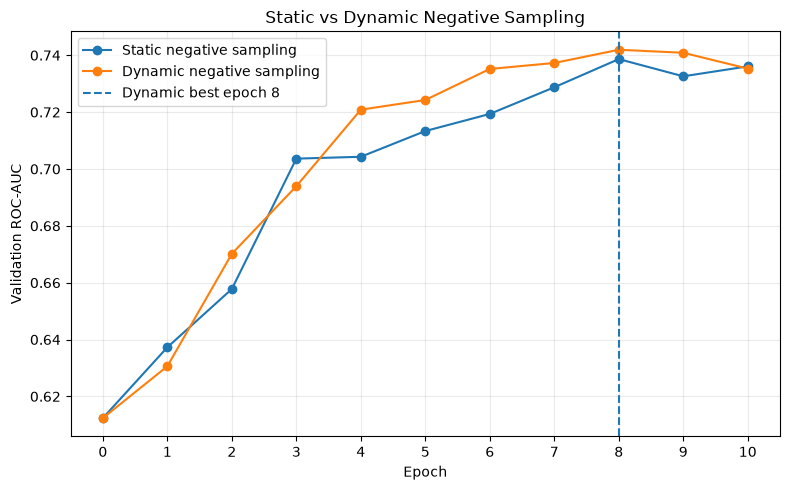

Training comparison saved: True
Validation AUC change: 0.003287
Official-test AUC change: 0.005827
Validation EER change: 0.0379 percentage points
Official-test EER change: -0.3454 percentage points


In [14]:
STATIC_HISTORY_PATH = (
    PROJECT_ROOT
    / "reports"
    / "supervised_metric_learning"
    / "training_history.csv"
)

static_history_df = pd.read_csv(
    STATIC_HISTORY_PATH
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    static_history_df[
        "epoch"
    ],
    static_history_df[
        "validation_roc_auc"
    ],
    marker="o",
    label="Static negative sampling",
)

ax.plot(
    training_history_df[
        "epoch"
    ],
    training_history_df[
        "validation_roc_auc"
    ],
    marker="o",
    label="Dynamic negative sampling",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Dynamic best epoch {best_epoch}",
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Validation ROC-AUC"
)

ax.set_title(
    "Static vs Dynamic Negative Sampling"
)

ax.set_xticks(
    range(
        0,
        EPOCHS + 1,
    )
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.tight_layout()

TRAINING_COMPARISON_PATH = (
    REPORT_DIR
    / "static_dynamic_validation_auc.png"
)

fig.savefig(
    TRAINING_COMPARISON_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

validation_aggregate_row = (
    aggregate_comparison_df[
        aggregate_comparison_df[
            "experiment_split"
        ] == "validation"
    ].iloc[0]
)

test_aggregate_row = (
    aggregate_comparison_df[
        aggregate_comparison_df[
            "experiment_split"
        ] == "official_test"
    ].iloc[0]
)

print(
    "Training comparison saved:",
    TRAINING_COMPARISON_PATH.exists(),
)

print(
    "Validation AUC change:",
    round(
        validation_aggregate_row[
            "auc_change"
        ],
        6,
    ),
)

print(
    "Official-test AUC change:",
    round(
        test_aggregate_row[
            "auc_change"
        ],
        6,
    ),
)

print(
    "Validation EER change:",
    round(
        validation_aggregate_row[
            "eer_change_points"
        ],
        4,
    ),
    "percentage points",
)

print(
    "Official-test EER change:",
    round(
        test_aggregate_row[
            "eer_change_points"
        ],
        4,
    ),
    "percentage points",
)

In [15]:
TRAINING_HISTORY_PATH = (
    REPORT_DIR
    / "training_history.csv"
)

PAIR_SCHEDULE_PATH = (
    REPORT_DIR
    / "dynamic_training_pair_schedule.csv"
)

EPOCH_SUMMARY_PATH = (
    REPORT_DIR
    / "epoch_pair_summary.csv"
)

NEGATIVE_EXPOSURE_PATH = (
    REPORT_DIR
    / "negative_writer_exposure.csv"
)

CONDITION_RESULTS_PATH = (
    REPORT_DIR
    / "verification_condition_results.csv"
)

STATIC_DYNAMIC_PATH = (
    REPORT_DIR
    / "static_dynamic_condition_comparison.csv"
)

SCRIPT_FAMILY_PATH = (
    REPORT_DIR
    / "script_family_summary.csv"
)

SCRIPT_GAP_PATH = (
    REPORT_DIR
    / "script_gap_comparison.csv"
)

OPERATING_POINT_PATH = (
    REPORT_DIR
    / "fixed_far_operating_points.csv"
)

FAR_COMPARISON_PATH = (
    REPORT_DIR
    / "fixed_far_static_dynamic_comparison.csv"
)

SUMMARY_PATH = (
    REPORT_DIR
    / "dynamic_sampling_summary.json"
)

training_history_df.to_csv(
    TRAINING_HISTORY_PATH,
    index=False,
)

dynamic_training_pairs_df.to_csv(
    PAIR_SCHEDULE_PATH,
    index=False,
)

epoch_pair_summary_df.to_csv(
    EPOCH_SUMMARY_PATH,
)

impostor_exposure_df.to_csv(
    NEGATIVE_EXPOSURE_PATH,
    index=False,
)

dynamic_condition_results_df.to_csv(
    CONDITION_RESULTS_PATH,
    index=False,
)

static_dynamic_comparison_df.to_csv(
    STATIC_DYNAMIC_PATH,
    index=False,
)

sampling_family_summary_df.to_csv(
    SCRIPT_FAMILY_PATH,
    index=False,
)

sampling_gap_df.to_csv(
    SCRIPT_GAP_PATH,
    index=False,
)

sampling_operating_df.to_csv(
    OPERATING_POINT_PATH,
    index=False,
)

sampling_far_comparison_df.to_csv(
    FAR_COMPARISON_PATH,
    index=False,
)

validation_gap_rows = sampling_gap_df[
    sampling_gap_df[
        "experiment_split"
    ] == "validation"
]

test_gap_rows = sampling_gap_df[
    sampling_gap_df[
        "experiment_split"
    ] == "official_test"
]

validation_static_gap = (
    validation_gap_rows.loc[
        validation_gap_rows[
            "sampling_strategy"
        ] == "static",
        "within_minus_cross_auc_gap",
    ].iloc[0]
)

validation_dynamic_gap = (
    validation_gap_rows.loc[
        validation_gap_rows[
            "sampling_strategy"
        ] == "dynamic",
        "within_minus_cross_auc_gap",
    ].iloc[0]
)

test_static_gap = (
    test_gap_rows.loc[
        test_gap_rows[
            "sampling_strategy"
        ] == "static",
        "within_minus_cross_auc_gap",
    ].iloc[0]
)

test_dynamic_gap = (
    test_gap_rows.loc[
        test_gap_rows[
            "sampling_strategy"
        ] == "dynamic",
        "within_minus_cross_auc_gap",
    ].iloc[0]
)

dynamic_summary = {
    "training_protocol": {
        "writers": 226,
        "epochs": EPOCHS,
        "pairs_per_epoch": 452,
        "genuine_pairs_per_epoch": 226,
        "impostor_pairs_per_epoch": 226,
        "distinct_negative_writers_per_anchor": 10,
        "epoch_offsets": (
            epoch_offsets.tolist()
        ),
        "best_epoch": int(
            best_epoch
        ),
    },
    "validation": {
        "roc_auc": float(
            best_validation_metrics[
                "roc_auc"
            ]
        ),
        "eer_percent": float(
            best_validation_metrics[
                "eer_percent"
            ]
        ),
        "auc_change_vs_static": float(
            validation_aggregate_row[
                "auc_change"
            ]
        ),
        "eer_change_points_vs_static": float(
            validation_aggregate_row[
                "eer_change_points"
            ]
        ),
    },
    "official_test": {
        "roc_auc": float(
            best_test_metrics[
                "roc_auc"
            ]
        ),
        "eer_percent": float(
            best_test_metrics[
                "eer_percent"
            ]
        ),
        "auc_change_vs_static": float(
            test_aggregate_row[
                "auc_change"
            ]
        ),
        "eer_change_points_vs_static": float(
            test_aggregate_row[
                "eer_change_points"
            ]
        ),
    },
    "cross_script_gap": {
        "validation_static": float(
            validation_static_gap
        ),
        "validation_dynamic": float(
            validation_dynamic_gap
        ),
        "official_test_static": float(
            test_static_gap
        ),
        "official_test_dynamic": float(
            test_dynamic_gap
        ),
    },
    "condition_comparisons": {
        "auc_improved": int(
            (
                condition_only_df[
                    "auc_change"
                ] > 0
            ).sum()
        ),
        "eer_improved": int(
            (
                condition_only_df[
                    "eer_change_points"
                ] < 0
            ).sum()
        ),
        "total": int(
            len(
                condition_only_df
            )
        ),
    },
    "skipped_optimizer_steps": int(
        training_history_df[
            "skipped_steps"
        ].sum()
    ),
}

with SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        dynamic_summary,
        file,
        indent=2,
    )

saved_paths = [
    TRAINING_HISTORY_PATH,
    PAIR_SCHEDULE_PATH,
    EPOCH_SUMMARY_PATH,
    NEGATIVE_EXPOSURE_PATH,
    CONDITION_RESULTS_PATH,
    STATIC_DYNAMIC_PATH,
    SCRIPT_FAMILY_PATH,
    SCRIPT_GAP_PATH,
    OPERATING_POINT_PATH,
    FAR_COMPARISON_PATH,
    SUMMARY_PATH,
    TRAINING_COMPARISON_PATH,
]

for path in saved_paths:
    print(
        path.name,
        ":",
        path.exists(),
    )

print()
print(
    "Best epoch:",
    best_epoch,
)

print(
    "Validation ROC-AUC:",
    round(
        best_validation_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Official-test ROC-AUC:",
    round(
        best_test_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Validation cross-script gap:",
    round(
        validation_dynamic_gap,
        4,
    ),
)

print(
    "Official-test cross-script gap:",
    round(
        test_dynamic_gap,
        4,
    ),
)

print(
    "AUC-improved conditions:",
    dynamic_summary[
        "condition_comparisons"
    ][
        "auc_improved"
    ],
    "of 12",
)

assert all(
    path.exists()
    for path in saved_paths
)

training_history.csv : True
dynamic_training_pair_schedule.csv : True
epoch_pair_summary.csv : True
negative_writer_exposure.csv : True
verification_condition_results.csv : True
static_dynamic_condition_comparison.csv : True
script_family_summary.csv : True
script_gap_comparison.csv : True
fixed_far_operating_points.csv : True
fixed_far_static_dynamic_comparison.csv : True
dynamic_sampling_summary.json : True
static_dynamic_validation_auc.png : True

Best epoch: 8
Validation ROC-AUC: 0.741935
Official-test ROC-AUC: 0.764084
Validation cross-script gap: 0.1256
Official-test cross-script gap: 0.1274
AUC-improved conditions: 5 of 12


## Writer-aware dynamic sampling conclusion

This experiment evaluated whether increasing negative-writer diversity improves supervised metric learning for writer verification.

The model architecture, loss, optimizer, training pages, positive pairs, batch size, and writer-disjoint validation protocol were kept identical to the previous supervised metric-learning baseline.

The only controlled change was negative sampling.

Instead of repeatedly pairing each anchor writer with the same impostor writer, the dynamic protocol exposed every anchor writer to 10 distinct negative writers across 10 epochs while preserving exactly one genuine and one impostor pair per writer per epoch.

### Aggregate performance

The best dynamic-sampling checkpoint was selected at epoch 8 using validation ROC-AUC only.

Compared with the previous static-negative metric-learning baseline:

- Validation ROC-AUC increased from 0.7386 to 0.7419
- Official-test ROC-AUC increased from 0.7583 to 0.7641
- Validation EER changed from 32.69% to 32.73%
- Official-test EER improved from 31.52% to 31.17%

The aggregate AUC improvements were therefore modest.

Across the 12 split-condition comparisons, dynamic sampling improved ROC-AUC in 5 conditions and reduced EER in 10 conditions.

### Cross-script behavior

The most important effect appeared in cross-script verification.

On validation writers:

- Static cross-script macro ROC-AUC: 0.6999
- Dynamic cross-script macro ROC-AUC: 0.7057
- Static within-minus-cross AUC gap: 0.1362
- Dynamic within-minus-cross AUC gap: 0.1256

On official-test writers:

- Static cross-script macro ROC-AUC: 0.7214
- Dynamic cross-script macro ROC-AUC: 0.7297
- Static within-minus-cross AUC gap: 0.1397
- Dynamic within-minus-cross AUC gap: 0.1274

Dynamic negative sampling therefore produced a small but consistent improvement in cross-script macro ROC-AUC and reduced the within-versus-cross-script gap in both evaluation splits.

However, within-script macro ROC-AUC decreased slightly.

This suggests that increasing negative-writer diversity changes the learned representation in a way that modestly improves cross-script generalization, rather than uniformly improving all verification conditions.

### Low-FAR behavior

Dynamic sampling did not consistently improve strict operating-point performance.

At validation operating points, dynamic sampling improved TAR only at approximately 10% FAR, while performance was lower at 5%, 1%, and 0.1% FAR compared with the static-negative metric-learning baseline.

The same pattern was observed on the official-test writers, where static sampling retained higher TAR at all evaluated fixed-FAR thresholds.

Therefore, dynamic negative exposure alone is not sufficient to improve practical low-FAR verification.

### Research implication

This controlled experiment demonstrates that sampling strategy matters, but richer random negative exposure provides only limited gains.

The result also strengthens the central research motivation:

- Writer-discriminative metric learning improves verification substantially.
- Increasing negative diversity can reduce the cross-script generalization gap.
- Neither approach produces strong low-FAR verification.
- Script-dependent representation behavior remains substantial.

The next stage should therefore move beyond pair-sampling refinements and investigate representation learning itself, beginning with self-supervised pretraining and later explicit script/content leakage analysis and script-invariant learning.

In [16]:
print(
    "Dynamic negative writers per anchor:",
    dynamic_summary[
        "training_protocol"
    ][
        "distinct_negative_writers_per_anchor"
    ],
)

print(
    "Best epoch:",
    dynamic_summary[
        "training_protocol"
    ][
        "best_epoch"
    ],
)

print(
    "Validation ROC-AUC:",
    round(
        dynamic_summary[
            "validation"
        ][
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Official-test ROC-AUC:",
    round(
        dynamic_summary[
            "official_test"
        ][
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Validation static → dynamic cross-script gap:",
    round(
        dynamic_summary[
            "cross_script_gap"
        ][
            "validation_static"
        ],
        4,
    ),
    "→",
    round(
        dynamic_summary[
            "cross_script_gap"
        ][
            "validation_dynamic"
        ],
        4,
    ),
)

print(
    "Official-test static → dynamic cross-script gap:",
    round(
        dynamic_summary[
            "cross_script_gap"
        ][
            "official_test_static"
        ],
        4,
    ),
    "→",
    round(
        dynamic_summary[
            "cross_script_gap"
        ][
            "official_test_dynamic"
        ],
        4,
    ),
)

print(
    "AUC-improved conditions:",
    dynamic_summary[
        "condition_comparisons"
    ][
        "auc_improved"
    ],
    "of",
    dynamic_summary[
        "condition_comparisons"
    ][
        "total"
    ],
)

print(
    "EER-improved conditions:",
    dynamic_summary[
        "condition_comparisons"
    ][
        "eer_improved"
    ],
    "of",
    dynamic_summary[
        "condition_comparisons"
    ][
        "total"
    ],
)

print(
    "Skipped optimizer steps:",
    dynamic_summary[
        "skipped_optimizer_steps"
    ],
)

print(
    "Notebook 12 complete:",
    True,
)

Dynamic negative writers per anchor: 10
Best epoch: 8
Validation ROC-AUC: 0.741935
Official-test ROC-AUC: 0.764084
Validation static → dynamic cross-script gap: 0.1362 → 0.1256
Official-test static → dynamic cross-script gap: 0.1397 → 0.1274
AUC-improved conditions: 5 of 12
EER-improved conditions: 10 of 12
Skipped optimizer steps: 0
Notebook 12 complete: True
